# Machine Learning para a Análise (K-Means)

O agrupamento (clustering) é um amplo conjunto de técnicas para encontrar subgrupos de observações dentro de um conjunto de dados. Ao agrupar observações, buscamos identificar grupos de dados distintos entre si.
- Como não há uma variável resposta (rótulo), este é um método não supervisionado, o que implica que ele encontra relações entre as observações sem treinamento. O agrupamento nos permite identificar quais observações são semelhantes e, potencialmente, categorizá-las.
- O agrupamento `K-means` é o método de clusterização mais simples e mais comumente usado para dividir um conjunto de dados em um conjunto de k grupos
- Para o projeto, o desafio é: como podemos agrupar esses milhares de imóveis de forma lógica e imparcial, baseando-nos exclusivamente em sua estrutura física e valor financeiro?

O algoritmo de clusterização **K-Means** é a ferramenta ideal para este cenário pelas seguintes razões:

* **Agrupamento por Similaridade Multidimensional:** O modelo utiliza o cálculo de Distâncias Euclidianas para encontrar padrões naturais nos dados. Ele agrupa imóveis que são matematicamente parecidos considerando todas as variáveis simultaneamente (Preço, Quartos, Camas e Banheiros).
* **Minimização da Variância:** O algoritmo busca criar grupos onde os imóveis dentro de um mesmo cluster sejam o mais semelhantes possível entre si, e o mais diferentes possível dos imóveis dos outros clusters.
* **Alta Interpretabilidade:** Diferente de algoritmos "caixa-preta", o K-Means cria centróides que nos permitem calcular a média exata de cada grupo, traduzindo o resultado matemático em "Perfis de Mercado" claros e diretamente acionáveis para o negócio.

Para que a magnitude do `price` (na casa das centenas) não anule o peso das variáveis estruturais (na casa das unidades), iniciaremos o pipeline aplicando a padronização dos dados (Feature Scaling).


## BIBLIOTECAS

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


## LEITURA DOS DADOS

In [7]:
dados = pd.read_csv('data/processed/dados_ml.csv', encoding='utf-8')
dados.shape

(17575, 13)

In [8]:
dados.info()


<class 'pandas.DataFrame'>
RangeIndex: 17575 entries, 0 to 17574
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17575 non-null  int64  
 1   listing_url             17575 non-null  str    
 2   neighbourhood_cleansed  17575 non-null  str    
 3   latitude                17575 non-null  float64
 4   longitude               17575 non-null  float64
 5   room_type               17575 non-null  str    
 6   accommodates            17575 non-null  int64  
 7   bathrooms               17575 non-null  float64
 8   bedrooms                17575 non-null  float64
 9   beds                    17575 non-null  float64
 10  price                   17575 non-null  float64
 11  review_scores_rating    14626 non-null  float64
 12  review_scores_value     14621 non-null  float64
dtypes: float64(8), int64(2), str(3)
memory usage: 1.7 MB


## MACHINE LEARNING - CLUSTER

### SELECIONAR AS VARIAVEIS

 - Não se usa variáveis identificadoras, para não ter viés com ID
 - Não é bom selecionar uma classe do anúncio e que pode enviesar e o algoritmo pode clusterizar por ela, como ROOM_TYPE, se não for o propósito
 - Não se usa variáveis categóricas (texto) em algoritmos de ML, é preciso converter para números
   - Em R é possível, por um tipo de dado **Factor**: variáveis categóricas que, por dentro, são tratadas como número para fins de modelagem e análise estatística

In [9]:
dados_cluster = dados[['bedrooms','beds','bathrooms','price']]

## EXCLUINDO VALORES NULOS PARA NÃO TER VÍES
dados_cluster = dados_cluster.dropna()

dados_cluster.shape

(17575, 4)

### MODELO

In [10]:
## CRIANDO MODELO KMEANS
# Utilizando três clusters para identificarmos categorias econômicas, padrão e luxo
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto') #3 grupos

## TREINANDO O MODELO KMEANS
kmeans.fit(dados_cluster)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [11]:
kmeans.labels_

array([1, 0, 0, ..., 1, 1, 0], shape=(17575,), dtype=int32)

In [12]:
## RECUPERANDO RÓTTULOS DOS CLUSTER
clusters = kmeans.labels_

## QUANTIDADE DE REGISTROS EM CADA GRUPO
print("QTD DE REGISTROS POR CLUSTER:")
print(pd.Series(clusters).value_counts())

QTD DE REGISTROS POR CLUSTER:
0    10451
1     5003
2     2121
Name: count, dtype: int64


- Quando há um cluster com poucos registros comparados com as variáveis selecionadas, isso indica que podem ser Outliers

### AVALIAR CLUSTER

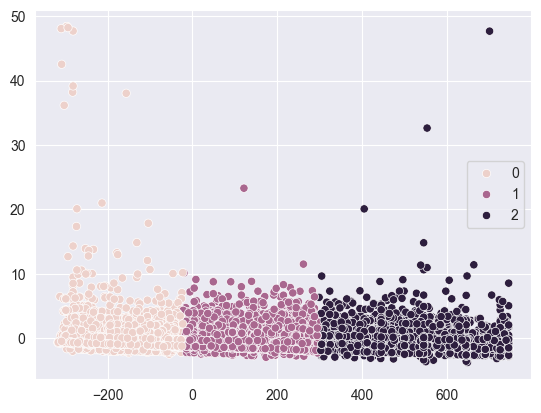

In [13]:
## ANALISE DE PCA
# para entender como os clusters se separaram
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(dados_cluster)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue = clusters)
plt.show()

In [14]:
##CRIANDO COLUNA NO DF PARA ARMARZANAR O RÓTULO DO CLUSTER
dados_cluster['CLUSTER'] = clusters
dados_cluster.head()

,bedrooms,beds,bathrooms,price,CLUSTER
0,2.0,4.0,1.0,507.0,1
1,1.0,1.0,1.0,215.0,0
2,2.0,4.0,1.0,90.0,0
3,2.0,3.0,2.0,769.0,2
4,1.0,2.0,1.5,351.0,1


### GERANDO BOXPLOT POR CLUSTER


#### PREÇO

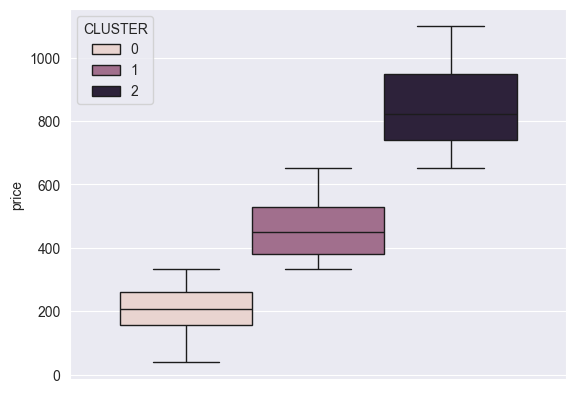

In [15]:
sns.boxplot(y = 'price', hue = 'CLUSTER', data = dados_cluster)
# para retirar outliers, acrescentar: showfliers=False

plt.show()

#### QUARTOS

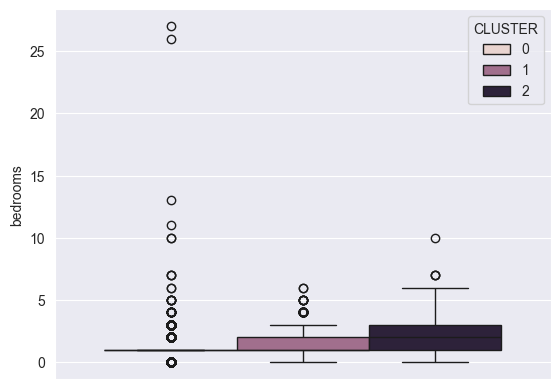

In [16]:
sns.boxplot(y = 'bedrooms', hue = 'CLUSTER', data = dados_cluster)
plt.show()

#### CAMAS

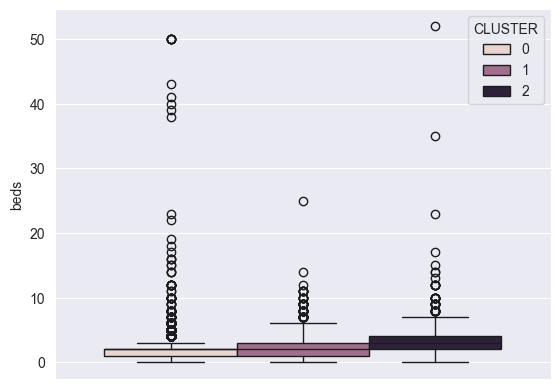

In [17]:
sns.boxplot(y = 'beds', hue = 'CLUSTER', data = dados_cluster)
plt.show()

#### BANHEIROS

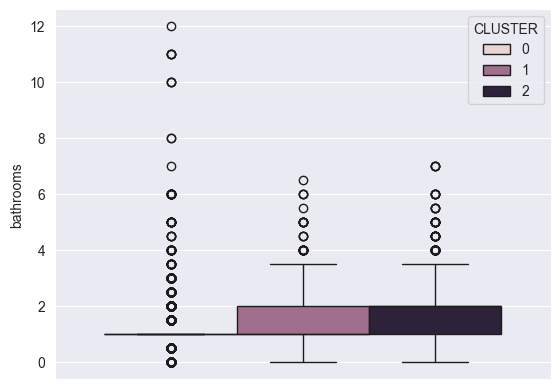

In [18]:
sns.boxplot(y = 'bathrooms', hue = 'CLUSTER', data = dados_cluster)
plt.show()

#### ANÁLISES
Analisando os cluster, podemos dizer que:
- cluster 0: imóveis com valores moderados, quantidade de quartos e banheiros intermediarios. Ou seja, imóveis `padrão`/popular
- cluster 1:  diária bem mais elevadas, mas ao mesmo tempo com uma quantidade de quartos e banheiros não tão elevado, ou seja, immóveis mais compactos mas de alto padrão, ióveis de luxo, pode ser em condominios, coberturadas etc.
- cluster 2: imóveis populares, com baixo valores de diária, a quantidade de quartos e banheiro relativamente pequenos, mas com muitos anomalias, ou seja, são imóveis mais simples. Pode ser hospedagem compartilhada, quartos privados etc.  

Usando apenas essas variáveis (quartos, camas, banheiros e preço), o algoritmos conseguiu separar as hospedagem em três perfis principais:
  - opções econômicas
  - imóveis padrão
  - imóveis de luxo.

E a partir desses resultados podemos identificar que a quantidade de quartos, camas e banheiros não está diretamente relacionado ao valor da diária, vide cluster 1 que tem os maiores valores da diária mas umas das menores quantidade dessas outras características.


---

## Uma metodologia para melhorar o uso do **KMeans**:
- `StandardScaler`: Como o K-means calcula distâncias, precisamos que o "peso" de 1 real seja comparável ao "peso" de 1 quarto. Ou seja, devem estar na mesma escala. Ele transforma os dados para que tenham média 0 e desvio padrão 1.

-  `Método do Cotovel`: Mostra matematicamente onde o ganho de informações para de valer a pena ao adicionar mais clusters, sendo uma forma de identificar qual a quantidade ideal clusters para a visualização.

In [19]:
# Selecionar apenas as colunas numéricas para o modelo
colunas_modelo = ['bedrooms', 'beds', 'bathrooms', 'price']
dados_para_escala = dados_cluster[colunas_modelo]

scaler = StandardScaler()
dados_escalonados = scaler.fit_transform(dados_para_escala)

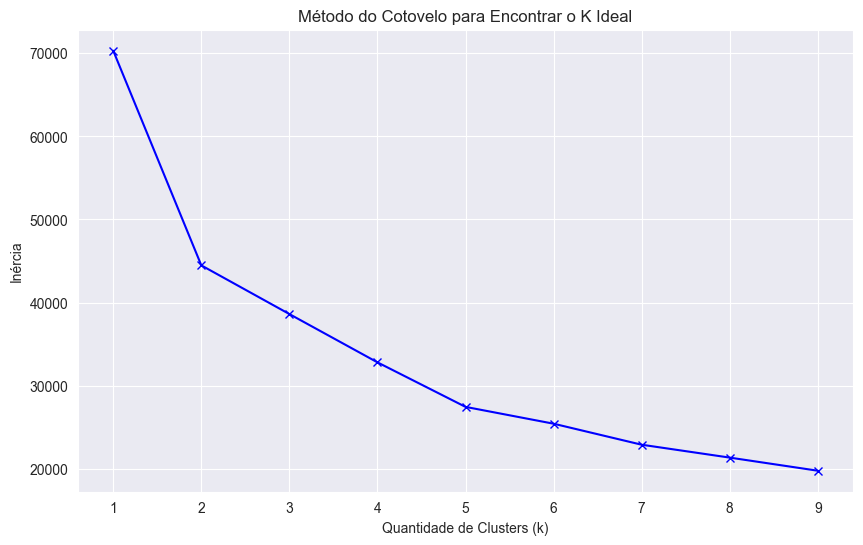

In [20]:
inercias = []
K = range(1, 10)

for k in K:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_teste.fit(dados_escalonados)
    inercias.append(kmeans_teste.inertia_)

# Plotar o gráfico do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(K, inercias, 'bx-')
plt.xlabel('Quantidade de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Encontrar o K Ideal')
plt.show()

- Como visto, o número de clusters a partir do 3 começa a perder muito mais, se fossem utilizados 4, o prejuízo poderia comprometer a análise final entre os tipos de hospedagens

In [21]:

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_final = kmeans_final.fit_predict(dados_escalonados)

# Adicionar os novos rótulos ao seu DataFrame original para análise
dados_cluster['CLUSTER_FINAL'] = clusters_final

In [22]:
kmeans.fit(dados_escalonados)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [23]:
X_pca = pca.fit_transform(dados_escalonados)

In [24]:
resumo_final = dados_cluster.groupby('CLUSTER_FINAL')[['price', 'bedrooms', 'bathrooms', 'beds']].mean()
resumo_final['contagem'] = dados_cluster['CLUSTER_FINAL'].value_counts()
display(resumo_final.sort_values(by='price'))

,price,bedrooms,bathrooms,beds,contagem
CLUSTER_FINAL,,,,,
0,240.133907,1.008081,1.051573,1.669534,11508
2,564.526232,1.737454,1.617245,2.486314,4384
1,605.352941,2.969103,2.696673,4.931670,1683


## Análise Final após a nova metodologia.
- Cluster 1 (Econômico): Focado em alta densidade (muitas camas) e baixo custo. Ideal para mochileiros.

- Cluster 0 (Padrão): Equilíbrio entre preço e conforto. Perfil familiar.

- Cluster 2 (Premium/Luxo): Propriedades exclusivas onde o preço não depende apenas do número de quartos, mas provavelmente da localização (outlier de valor).

### VALIDAÇÃO VISUAL DOS CLUSTERS FINAIS COM PCA
- O PCA (Principal Component Analysis) "espreme" as 4 variáveis (quartos, camas, banheiros, preço) em apenas 2 eixos (X e Y) para conseguirmos enxergar os grupos em um gráfico 2D.

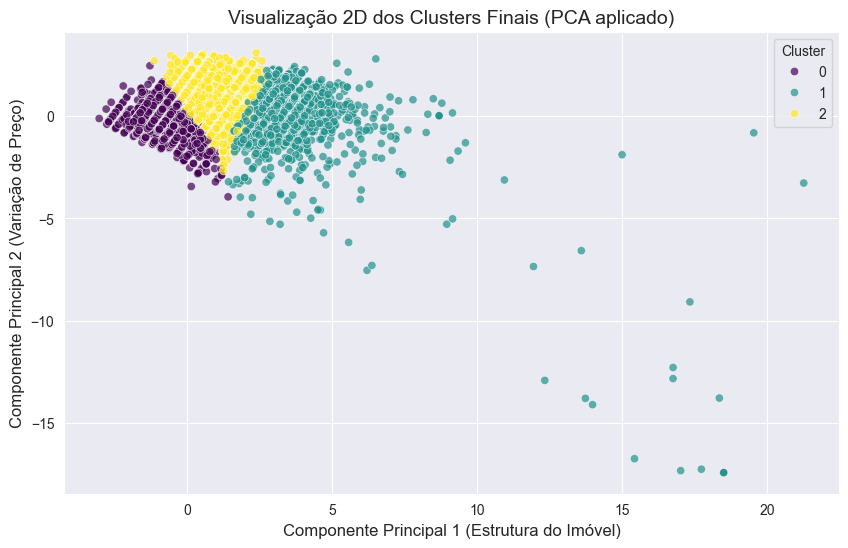

In [25]:
pca_final = PCA(n_components=2)
X_pca_final = pca_final.fit_transform(dados_escalonados)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_final[:, 0],
    y=X_pca_final[:, 1],
    hue=dados_cluster['CLUSTER_FINAL'],
    palette='viridis',
    alpha=0.7
)

plt.title('Visualização 2D dos Clusters Finais (PCA aplicado)', fontsize=14)
plt.xlabel('Componente Principal 1 (Estrutura do Imóvel)', fontsize=12)
plt.ylabel('Componente Principal 2 (Variação de Preço)', fontsize=12)
plt.legend(title='Cluster')
plt.show()